# Challenge 6 — Análisis de Logs Distribuidos
**Objetivo:** Detectar cuándo el sistema estuvo peor, qué servicio falló y qué cambió respecto al baseline.

## ⚙️ Setup — Importar librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Para que las tablas se vean completas
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.max_columns', 20)

print('Librerías cargadas OK ✅')

Librerías cargadas OK ✅


## 📦 Carga del dataset
Poné el CSV en la misma carpeta que este notebook y renombralo `logs.csv`, o cambiá el path abajo.

In [2]:
# ← Cambiá este path si tu archivo tiene otro nombre
CSV_PATH = 'server_logs.csv'

df = pd.read_csv(CSV_PATH)

# Convertir timestamp a datetime
df['timestamp_event'] = pd.to_datetime(df['timestamp_event'], utc=True)

print(f'Dataset cargado: {len(df):,} filas | {df.shape[1]} columnas')
print('\nColumnas disponibles:')
print(df.columns.tolist())

Dataset cargado: 5,795 filas | 15 columnas

Columnas disponibles:
['timestamp_event', 'received_at', 'service_name', 'severity', 'message', 'trace_id', 'request_id', 'method', 'endpoint', 'status_code', 'latency_ms', 'host', 'env', 'region', 'log_type']


In [3]:
# Vista rápida
df.head(3)

,timestamp_event,received_at,service_name,severity,message,trace_id,request_id,method,endpoint,status_code,latency_ms,host,env,region,log_type
0,2026-01-10 00:02:39.029160+00:00,2026-01-10T00:02:39.097160Z,orders-service,INFO,Request completed,bd8e6ebe717b4c43ba5e72e1668641a8,e6b3009adcad,GET,/orders/create,200,99,orders-service-pod-03,prod,sa-east-1,request
1,2026-01-10 00:02:46.081021+00:00,2026-01-10T00:02:46.196021Z,api-gateway,INFO,Background job completed,40ac5ff97bae43d5b8045484725e0aca,e2aa1cccd1cf,GET,/health,200,122,api-gateway-pod-01,prod,sa-east-1,request
2,2026-01-10 00:04:01.648849+00:00,2026-01-10T00:04:01.718849Z,notification-service,WARN,Rate limit nearing threshold,c048b378759a4c54a6f7d7251a6acc88,c74106ca8581,POST,/notify/sms,200,646,notification-service-pod-03,prod,sa-east-1,request


---
## 6.1 — Exploración inicial

In [4]:
# ¿Cuántos logs hay en total?
total_logs = len(df)
print(f'Total de logs: {total_logs:,}')

Total de logs: 5,795


In [5]:
# ¿Qué severidad aparece más?
print('=== Distribución de Severidad ===')
severity_counts = df['severity'].value_counts().reset_index()
severity_counts.columns = ['severity', 'count']
severity_counts['%'] = (severity_counts['count'] / total_logs * 100).round(2)
print(severity_counts.to_string(index=False))

=== Distribución de Severidad ===
severity  count     %
    INFO   3542 61.12
    WARN   1358 23.43
   ERROR    775 13.37
CRITICAL    120  2.07


In [6]:
# ¿Qué servicio genera más/menos logs?
print('=== Logs por Servicio ===')
service_counts = df['service_name'].value_counts().reset_index()
service_counts.columns = ['service_name', 'count']
print(service_counts.to_string(index=False))

print(f"\n🔝 Más logs:  {service_counts.iloc[0]['service_name']} ({service_counts.iloc[0]['count']:,})")
print(f"🔻 Menos logs: {service_counts.iloc[-1]['service_name']} ({service_counts.iloc[-1]['count']:,})")

=== Logs por Servicio ===
        service_name  count
         api-gateway   1509
      orders-service   1057
   inventory-service    964
     payment-service    842
        auth-service    778
notification-service    645

🔝 Más logs:  api-gateway (1,509)
🔻 Menos logs: notification-service (645)


In [7]:
# ¿Cuál es el mensaje más repetido?
print('=== Top 5 mensajes más repetidos (todos) ===')
top_msg = df['message'].value_counts().head(5).reset_index()
top_msg.columns = ['message', 'count']
print(top_msg.to_string(index=False))

=== Top 5 mensajes más repetidos (todos) ===
                                       message  count
                               Health check OK   1196
                      Background job completed   1185
                             Request completed   1161
Order creation failed - inventory lock timeout    197
                  Rate limit nearing threshold    193


In [8]:
# ¿Cuál es el mensaje 'malo' más repetido?
# Definición de bad event: severity ERROR/CRITICAL  o  status_code >= 500
mask_bad = (
    df['severity'].isin(['ERROR', 'CRITICAL']) |
    (df['status_code'] >= 500)
)
df_bad = df[mask_bad].copy()

print(f'Total de bad events: {len(df_bad):,} ({len(df_bad)/total_logs*100:.1f}% del total)\n')

print('=== Top 5 mensajes en bad events ===')
top_bad_msg = df_bad['message'].value_counts().head(5).reset_index()
top_bad_msg.columns = ['message', 'count']
print(top_bad_msg.to_string(index=False))

Total de bad events: 895 (15.4% del total)

=== Top 5 mensajes en bad events ===
                                       message  count
Order creation failed - inventory lock timeout    197
                   Payment gateway unavailable    103
                    Database deadlock detected     99
    Checkout failed - upstream payment timeout     88
         Possible credential stuffing detected     69


---
## 6.2 — Detección del Momento Crítico
Regla: ventanas de 5 minutos usando `timestamp_event`. Momento crítico = mayor `bad_rate` con `total_events >= 20`.

In [ ]:
# Crear columna de ventana de 5 minutos
df['window_5min'] = df['timestamp_event'].dt.floor('5min')
df_bad['window_5min'] = df_bad['timestamp_event'].dt.floor('5min')

# Agrupar
total_by_window = df.groupby('window_5min').size().rename('total_events')
bad_by_window   = df_bad.groupby('window_5min').size().rename('bad_events')

windows = pd.concat([total_by_window, bad_by_window], axis=1).fillna(0)
windows['bad_events'] = windows['bad_events'].astype(int)
windows['bad_rate']   = (windows['bad_events'] / windows['total_events']).round(4)
windows = windows.reset_index().rename(columns={'window_5min': 'window_start'})

# Top 5 por bad_rate (mínimo 20 eventos)
top5 = (
    windows[windows['total_events'] >= 20]
    .sort_values('bad_rate', ascending=False)
    .head(5)
    .reset_index(drop=True)
)

print('=== Top 5 ventanas con mayor bad_rate (total_events >= 20) ===')
df[print(top5[['window_start','total_events','bad_events','bad_rate']].to_string(index=False))]

=== Top 5 ventanas con mayor bad_rate (total_events >= 20) ===
             window_start  total_events  bad_events  bad_rate
2026-01-10 11:10:00+00:00           189         110    0.5820
2026-01-10 11:15:00+00:00           228         129    0.5658
2026-01-10 11:20:00+00:00           111          59    0.5315
2026-01-11 14:35:00+00:00           255         117    0.4588
2026-01-11 14:30:00+00:00           156          68    0.4359


In [10]:
# Momento crítico = top 1
momento_critico_row = top5.iloc[0]
MOMENTO_CRITICO = momento_critico_row['window_start']
MOMENTO_CRITICO_FIN = MOMENTO_CRITICO + pd.Timedelta(minutes=5)

print(f'🚨 MOMENTO CRÍTICO:')
print(f'   Ventana:      {MOMENTO_CRITICO} → {MOMENTO_CRITICO_FIN}')
print(f'   total_events: {momento_critico_row["total_events"]}')
print(f'   bad_events:   {momento_critico_row["bad_events"]}')
print(f'   bad_rate:     {momento_critico_row["bad_rate"]:.2%}')

🚨 MOMENTO CRÍTICO:
   Ventana:      2026-01-10 11:10:00+00:00 → 2026-01-10 11:15:00+00:00
   total_events: 189
   bad_events:   110
   bad_rate:     58.20%


---
## 6.3 — Diagnóstico dentro del Momento Crítico
**Criterio elegido: cantidad de bad events**

In [ ]:
# Filtrar solo los eventos del momento crítico
mask_critico = (
    (df['timestamp_event'] >= MOMENTO_CRITICO) &
    (df['timestamp_event'] <  MOMENTO_CRITICO_FIN)
)
df_critico      = df[mask_critico].copy()
df_critico_bad  = df_critico[mask_bad.reindex(df_critico.index, fill_value=False)].copy()

# Alternativa más robusta para filtrar bad dentro del crítico
mask_bad_critico = (
    df_critico['severity'].isin(['ERROR', 'CRITICAL']) |
    (df_critico['status_code'] >= 500)
)
df_critico_bad = df_critico[mask_bad_critico]

print(f'Eventos en el momento crítico: {len(df_critico):,}')
print(f'Bad events en el momento crítico: {len(df_critico_bad):,}')

Eventos en el momento crítico: 189
Bad events en el momento crítico: 110


In [ ]:
# Bad events por servicio (ranking)
print('=== Bad events por servicio (momento crítico) ===')
bad_by_service = (
    df_critico_bad['service_name']
    .value_counts()
    .reset_index()
)
bad_by_service.columns = ['service_name', 'bad_events']
print(bad_by_service.to_string(index=False))

=== Bad events por servicio (momento crítico) ===
     service_name  bad_events
   orders-service          72
inventory-service          37
  payment-service           1


In [ ]:
# Top 5 mensajes en bad events del momento crítico
print('=== Top 5 mensajes en bad events (momento crítico) ===')
top5_msg_critico = (
    df_critico_bad['message']
    .value_counts()
    .head(5)
    .reset_index()
)
top5_msg_critico.columns = ['message', 'count']
print(top5_msg_critico.to_string(index=False))

=== Top 5 mensajes en bad events (momento crítico) ===
                                       message  count
Order creation failed - inventory lock timeout     72
                    Database deadlock detected     37
                     External dependency error      1


In [ ]:
# Top 5 endpoints más comprometidos (por cantidad de bad events)
print('=== Top 5 endpoints más comprometidos (momento crítico) ===')
top5_endpoints = (
    df_critico_bad['endpoint']
    .value_counts()
    .head(5)
    .reset_index()
)
top5_endpoints.columns = ['endpoint', 'bad_events']
print(top5_endpoints.to_string(index=False))

=== Top 5 endpoints más comprometidos (momento crítico) ===
      endpoint  bad_events
/orders/cancel          26
/orders/create          25
/orders/status          21
  /inv/reserve          18
    /inv/stock          13


---
## 6.4 — ¿Qué cambió? Incidente vs Baseline

In [ ]:
# Baseline = todo fuera del momento crítico
df_baseline = df[~mask_critico].copy()

def resumir(data, label):
    mask_b = (
        data['severity'].isin(['ERROR', 'CRITICAL']) |
        (data['status_code'] >= 500)
    )
    total    = len(data)
    bad      = mask_b.sum()
    bad_rate = bad / total if total > 0 else 0
    avg_lat  = data['latency_ms'].mean()
    pct_5xx  = (data['status_code'] >= 500).sum() / total * 100 if total > 0 else 0
    return {
        'periodo': label,
        'total_events': total,
        'bad_rate': round(bad_rate, 4),
        'avg_latency_ms': round(avg_lat, 1),
        '%_5xx': round(pct_5xx, 2)
    }

comparacion = pd.DataFrame([
    resumir(df_critico, 'Momento crítico'),
    resumir(df_baseline, 'Baseline')
])

print('=== Comparación: Momento Crítico vs Baseline ===')
pd.DataFrame(comparacion.to_string(index=False))

=== Comparación: Momento Crítico vs Baseline ===
        periodo  total_events  bad_rate  avg_latency_ms  %_5xx
Momento crítico           189     0.582          1589.7   58.2
       Baseline          5606     0.140           521.1   14.0


---
## 📊 Gráfico 1 — Eventos por severidad en bins de 5 min

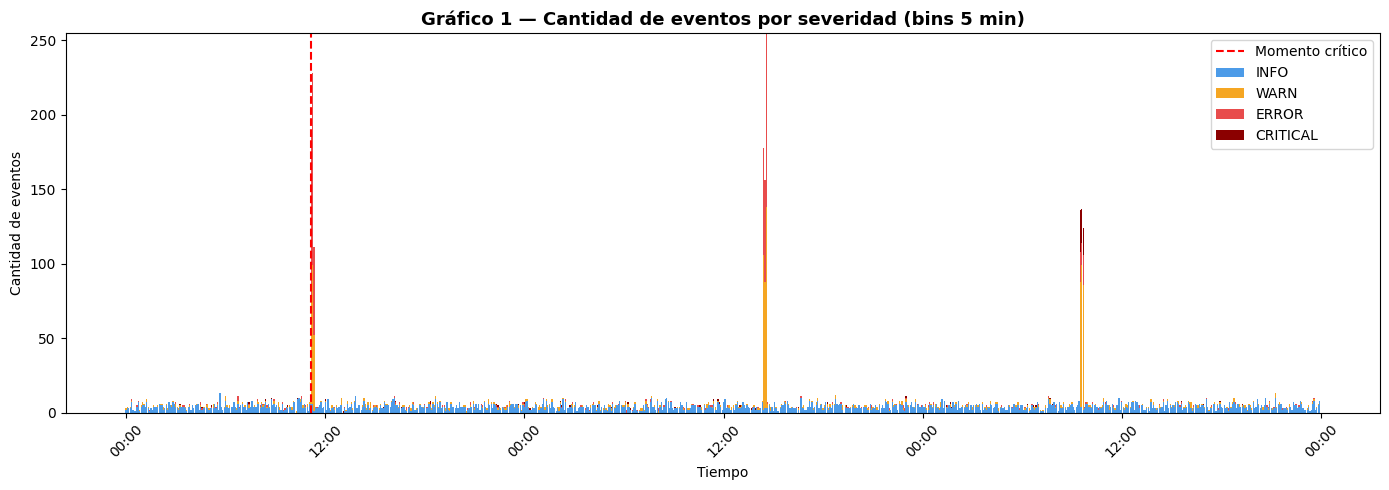

Gráfico 1 guardado como grafico1_severidad.png


In [16]:
# Pivot: ventana x severidad
sev_by_window = (
    df.groupby(['window_5min', 'severity'])
    .size()
    .unstack(fill_value=0)
)

# Ordenar columnas si existen
cols_orden = [c for c in ['INFO', 'WARN', 'ERROR', 'CRITICAL'] if c in sev_by_window.columns]
sev_by_window = sev_by_window[cols_orden]

colores = {'INFO': '#4C9BE8', 'WARN': '#F5A623', 'ERROR': '#E84C4C', 'CRITICAL': '#8B0000'}

fig, ax = plt.subplots(figsize=(14, 5))

bottom = None
for sev in cols_orden:
    vals = sev_by_window[sev].values
    ax.bar(
        sev_by_window.index,
        vals,
        bottom=bottom,
        label=sev,
        color=colores.get(sev, 'gray'),
        width=pd.Timedelta(minutes=4.5)
    )
    bottom = vals if bottom is None else bottom + vals

# Línea del momento crítico
ax.axvline(MOMENTO_CRITICO, color='red', linestyle='--', linewidth=1.5, label='Momento crítico')

ax.set_title('Gráfico 1 — Cantidad de eventos por severidad (bins 5 min)', fontsize=13, fontweight='bold')
ax.set_xlabel('Tiempo')
ax.set_ylabel('Cantidad de eventos')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('grafico1_severidad.png', dpi=120)
plt.show()
print('Gráfico 1 guardado como grafico1_severidad.png')

## 📊 Gráfico 2 — Bad rate (% errores) en bins de 5 min

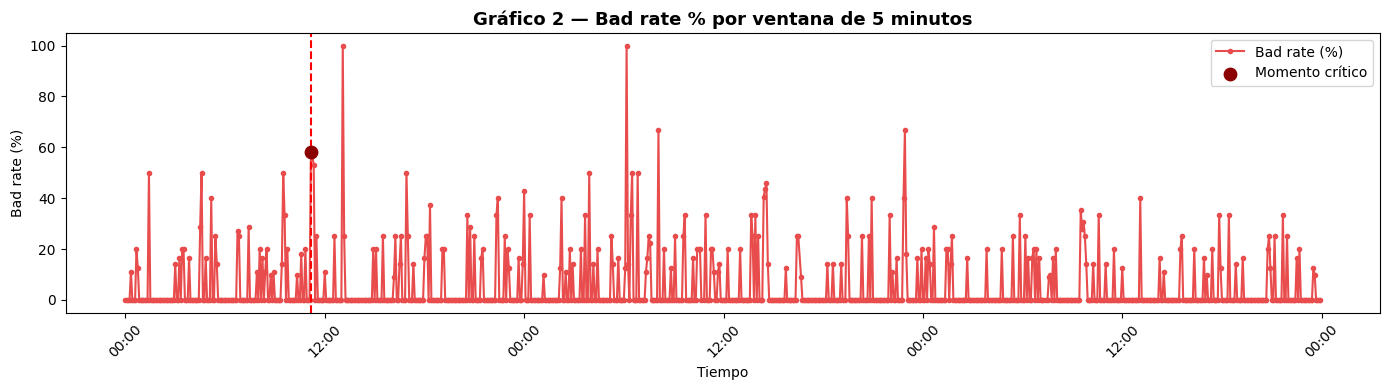

Gráfico 2 guardado como grafico2_badrate.png


In [17]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(
    windows['window_start'],
    windows['bad_rate'] * 100,
    color='#E84C4C',
    linewidth=1.5,
    marker='o',
    markersize=3,
    label='Bad rate (%)'
)

# Resaltar el momento crítico
mc_row = windows[windows['window_start'] == MOMENTO_CRITICO]
if not mc_row.empty:
    ax.scatter(
        mc_row['window_start'],
        mc_row['bad_rate'] * 100,
        color='darkred', s=80, zorder=5, label='Momento crítico'
    )

ax.axvline(MOMENTO_CRITICO, color='red', linestyle='--', linewidth=1.5)
ax.set_title('Gráfico 2 — Bad rate % por ventana de 5 minutos', fontsize=13, fontweight='bold')
ax.set_xlabel('Tiempo')
ax.set_ylabel('Bad rate (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('grafico2_badrate.png', dpi=120)
plt.show()
print('Gráfico 2 guardado como grafico2_badrate.png')

---


In [18]:
# Elegir un trace_id que tenga al menos 1 bad event en el momento crítico
if 'trace_id' in df.columns:
    trace_candidatos = df_critico_bad['trace_id'].value_counts()
    if not trace_candidatos.empty:
        trace_elegido = trace_candidatos.index[0]
        print(f'Trace elegido: {trace_elegido}')

        df_trace = (
            df[df['trace_id'] == trace_elegido]
            .sort_values('timestamp_event')
            [['timestamp_event','service_name','endpoint','status_code','severity','message']]
        )

        print(f'\nSecuencia del trace ({len(df_trace)} eventos):')
        print(df_trace.to_string(index=False))

        # Primer bad event del trace
        mask_bad_trace = (
            df_trace['severity'].isin(['ERROR','CRITICAL']) |
            (df_trace['status_code'] >= 500)
        )
        primer_bad = df_trace[mask_bad_trace].iloc[0] if mask_bad_trace.any() else None
        if primer_bad is not None:
            print(f'\n⚠️  Primer bad event del trace:')
            print(primer_bad.to_string())
    else:
        print('No hay trace_ids con bad events en el momento crítico.')
else:
    print('El dataset no tiene columna trace_id.')

Trace elegido: e06c4ed1570f46efa88fde74338d9edd

Secuencia del trace (3 eventos):
                 timestamp_event      service_name       endpoint  status_code severity                                        message
2026-01-10 11:10:03.851393+00:00    orders-service /orders/create          504    ERROR Order creation failed - inventory lock timeout
2026-01-10 11:10:03.856393+00:00       api-gateway      /checkout          200     WARN     Inventory endpoint degraded - high latency
2026-01-10 11:10:04.134393+00:00 inventory-service   /inv/reserve          504    ERROR                     Database deadlock detected

⚠️  Primer bad event del trace:
timestamp_event                  2026-01-10 11:10:03.851393+00:00
service_name                                       orders-service
endpoint                                           /orders/create
status_code                                                   504
severity                                                    ERROR
message        